**BEUST Léna**
_____________________
# **Activity recognition**


### Download Data

The data is taken from http://archive.ics.uci.edu/ml/machine-learning-databases/00240/, but you can have it in the form of the UCI-HAR-Dataset.zip.

Extract it to the folder of your notebook with the solution (or suitably adjust the paths to training and test data specified below (TRAIN, TEST).  

Spcifically, the split into training and testing data is already done. The dataset contains 7352 training and 2947 test samples.  

Each sample consists of nine timeseries of float values, each of length 128.

The nine timeseries are collected by an accelerometer and a gyroscope that contain information about the motion and the orientation, respectively.

In [3]:
import os

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

### Load Data

In [4]:
# Useful Constants
TRAIN = "UCI_HAR_Dataset/train/"
TEST = "UCI_HAR_Dataset/test/"

# x-values, 'signals'
# Those are separate normalised input features for the neural network
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]
X_train_signals_paths = [TRAIN + "Inertial Signals/" + signal + "train.txt" for signal in INPUT_SIGNAL_TYPES]
X_test_signals_paths =  [TEST  + "Inertial Signals/" + signal + "test.txt"  for signal in INPUT_SIGNAL_TYPES]


# y-values, 'labels'
#Output classes to learn how to classify
LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]
N_CLASSES = len(LABELS)
y_train_path = TRAIN + "y_train.txt"
y_test_path  = TEST  + "y_test.txt"

In [5]:
# Load "X" (the neural network's training and testing inputs)
def load_X(X_signals_paths):
    X_signals = []
    for signal_type_path in X_signals_paths:
        file = open(signal_type_path, 'r')
        # Read dataset from disk, dealing with text files' syntax
        X_signals.append(
            [np.array(serie, dtype=np.float32) for serie in [
                row.replace('  ', ' ').strip().split(' ') for row in file
            ]]
        )
        file.close()
    return np.transpose(np.array(X_signals), (1, 2, 0))

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)
print(X_train.shape, X_test.shape)

(7352, 128, 9) (2947, 128, 9)


In [6]:
# Load "y" (the neural network's training and testing outputs)
def load_y(y_path):
    file = open(y_path, 'r')
    # Read dataset from disk, dealing with text file's syntax
    y_ = np.array(
        [elem for elem in [
            row.replace('  ', ' ').strip().split(' ') for row in file
        ]],
        dtype=np.int32
    )
    file.close()
    # Substract 1 to each output class for friendly 0-based indexing
    return y_ - 1

def one_hot(y, n_classes):
    y = y.reshape(len(y))
    return np.eye(n_classes)[np.array(y, dtype=np.int32)]

def label_from_onehot(vectors):
    indices = []
    for vector in vectors:
        indices.append(np.argmax(vector))
    return np.array(indices)

Y_train = load_y(y_train_path)
Y_test = load_y(y_test_path)
print(Y_train.shape, Y_test.shape)

(7352, 1) (2947, 1)


#### Plot some samples

In [7]:
X_train_per_class = {}
for c in range(N_CLASSES):
    mask = ... # select sample of given class c
    X_train_per_class[c] = X_train[mask]

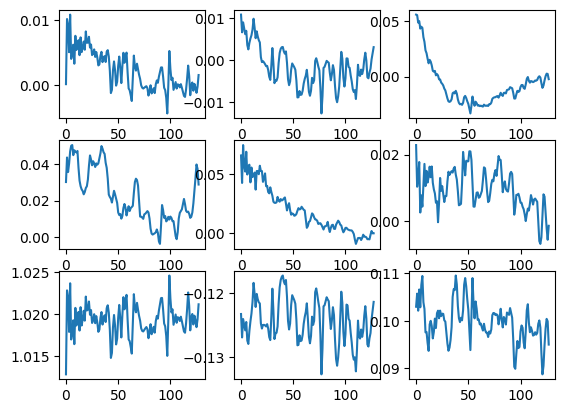

In [8]:
def plot_lines(X, nsamples):
    t = range(128)
    for i in range(9):
        plt.subplot(3,3,i+1)
        for j in range(np.minimum(X.shape[0],nsamples)):
            plt.plot(t,X[j,:,i])
    plt.show()
    
plot_lines(X_train_per_class[1], 1)

In [9]:
# Input Data
training_data_count = len(X_train)  # 7352 training series (with 50% overlap between each serie)
test_data_count = len(X_test)  # 2947 testing series
means = np.mean(X_train, axis=(0,1))
stdevs = np.std(X_train, axis=(0,1))

print("X shape, Y_shape:")
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)
print()
print("Mean / Stdev for each feature:")
for i in range(9):
    print("%7.4f | %7.4f"%(means[i], stdevs[i]))

X shape, Y_shape:
(7352, 128, 9) (7352, 1)
(2947, 128, 9) (2947, 1)

Mean / Stdev for each feature:
-0.0006 |  0.1948
-0.0003 |  0.1224
-0.0003 |  0.1069
 0.0005 |  0.4068
-0.0008 |  0.3819
 0.0001 |  0.2557
 0.8047 |  0.4141
 0.0288 |  0.3910
 0.0865 |  0.3578


### Dataset

If suitable specify Dataset (e.g. in PyTorch).

In [10]:
n_classes = len(LABELS)
n_steps = X_train.shape[1]
n_input = X_train.shape[2]

In [11]:
from tensorflow.keras.utils import to_categorical

# One-hot encode Y_train and Y_test
Y_train = to_categorical(Y_train, num_classes=n_classes)
Y_test = to_categorical(Y_test, num_classes=n_classes)

2026-05-04 17:00:59.010983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-04 17:00:59.024548: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-04 17:00:59.024568: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-04 17:00:59.032480: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 17:01:00.041837: W tensorflow/compiler/tf

### Normalization

...

## Specify and Train Models

Try different architectures to solve the activity recognition problem.

At minimum implement
* Model with a single layer of SimpleRNN
* Model with a single layer of LSTM
* Model with several layers of LSTMs
* Model with several CNN layers
* MLP

Try with different number of units. Add regularisation if needed (e.g. when working with MLPs).

Report about your findings.

In [12]:
import tensorflow as tf

### Single Layer SimpleRNN

In [13]:
### START YOUR CODE

n_hidden = 32
alpha = 0.001
clipnorm = 0.2

model1 = tf.keras.Sequential()
model1.add(tf.keras.layers.SimpleRNN(units=n_hidden, return_sequences=False, activation='tanh', input_shape=(n_steps,n_input)))
model1.add(tf.keras.layers.Dense(n_classes, activation='softmax'))

optimizer = tf.keras.optimizers.RMSprop(alpha, clipnorm)

model1.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model1.summary()

### END YOUR CODE

2026-05-04 17:01:04.537972: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-04 17:01:04.618231: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,542 (6.02 KB)

 Trainable params: 1,542 (6.02 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
### START YOUR CODE
history1 = model1.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss1, test_acc1 = model1.evaluate(X_test, Y_test)
print(f"\nAccuracy: {test_acc1:.4f}")

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4400 - loss: 1.3402 - val_accuracy: 0.5584 - val_loss: 1.0691
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5667 - loss: 1.0539 - val_accuracy: 0.6658 - val_loss: 0.8352
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6200 - loss: 0.8974 - val_accuracy: 0.6345 - val_loss: 0.7945
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6501 - loss: 0.8004 - val_accuracy: 0.6495 - val_loss: 0.7581
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6714 - loss: 0.7163 - val_accuracy: 0.6590 - val_loss: 0.6939
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6980 - loss: 0.6648 - val_accuracy: 0.6929 - val_loss: 0.6665
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7338 - loss: 0.6164 - val_accuracy: 0.7269 - val_loss: 0.6797
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7715 - loss: 0.5816 - val_accuracy: 0

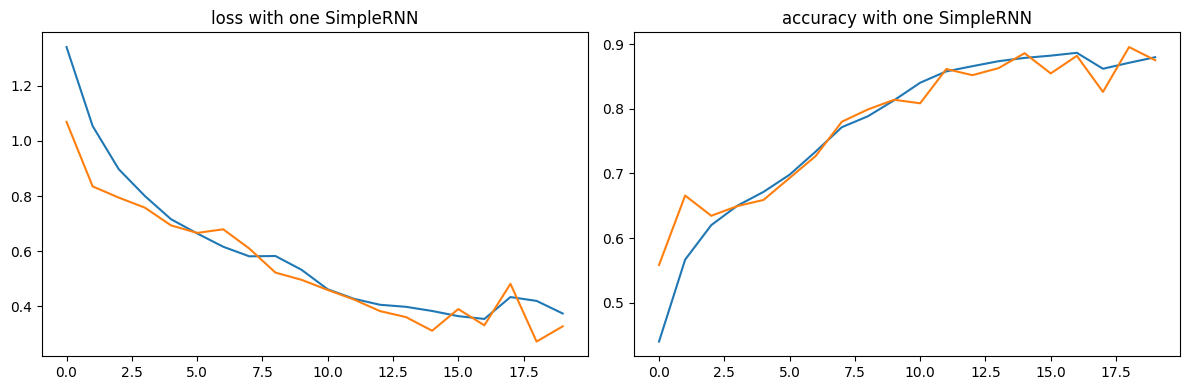

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history1.history['loss'],     label='train')
ax1.plot(history1.history['val_loss'], label='val')
ax1.set_title('loss with one SimpleRNN')
ax2.plot(history1.history['accuracy'],     label='train')
ax2.plot(history1.history['val_accuracy'], label='val')
ax2.set_title("accuracy with one SimpleRNN")
plt.tight_layout()
plt.show()

#### Findings

The final accuracy is **76.69%**. The learning is very unstable with irregular siginificant drops performance (particularly at the end of the training phase). The model is too simple with a just layer of SimpleRNN. 

### LSTM

In [26]:
### START YOUR CODE

n_hidden = 128

model2 = tf.keras.Sequential()
model2.add(tf.keras.layers.LSTM(units=n_hidden, return_sequences=False, input_shape=(n_steps, n_input)))
model2.add(tf.keras.layers.Dense(n_classes, activation="softmax"))

model2.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

model2.summary()

### END YOUR CODE

/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,430 (279.02 KB)

 Trainable params: 71,430 (279.02 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
### START YOUR CODE
history2 = model2.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss2, test_acc2 = model2.evaluate(X_test, Y_test)
print(f"\nAccuracy: {test_acc2:.4f}")

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.4947 - loss: 1.1791 - val_accuracy: 0.5842 - val_loss: 0.8489
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.6711 - loss: 0.7775 - val_accuracy: 0.7024 - val_loss: 0.6234
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.7235 - loss: 0.7148 - val_accuracy: 0.7024 - val_loss: 0.7520
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8047 - loss: 0.5578 - val_accuracy: 0.5802 - val_loss: 1.1908
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8085 - loss: 0.5467 - val_accuracy: 0.8954 - val_loss: 0.2910
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9146 - loss: 0.2658 - val_accuracy: 0.9198 - val_loss: 0.1896
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9089 - loss: 0.2917 - val_accuracy: 0.8709 - val_loss: 0.2842
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.9341 - loss: 0.1994 - val_accu

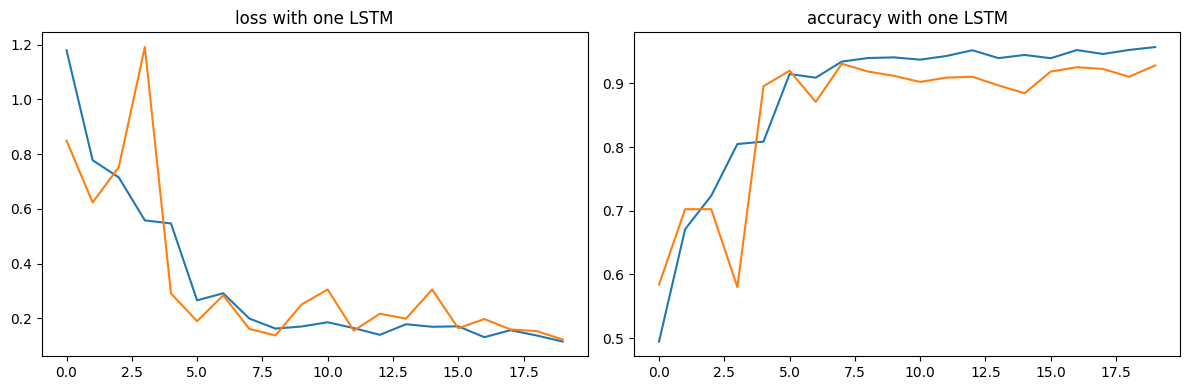

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history2.history['loss'],     label='train')
ax1.plot(history2.history['val_loss'], label='val')
ax1.set_title('loss with one LSTM')
ax2.plot(history2.history['accuracy'],     label='train')
ax2.plot(history2.history['val_accuracy'], label='val')
ax2.set_title("accuracy with one LSTM")
plt.tight_layout()
plt.show()

#### Findings

With 20 epochs, a batch size of 64 and a nunits of 128, we achieve an accuracy of **90.74%** without overfitting and a stabler training process.

### Stacked LSTMs

In [16]:
### START YOUR CODE

model3 = tf.keras.Sequential()
model3.add(tf.keras.layers.LSTM(units=16, return_sequences=True, input_shape=(n_steps, n_input)))
model3.add(tf.keras.layers.LSTM(units=32, return_sequences=True, input_shape=(n_steps, n_input)))
model3.add(tf.keras.layers.LSTM(units=64, return_sequences=False, input_shape=(n_steps, n_input)))
model3.add(tf.keras.layers.Dense(n_classes, activation="softmax"))

model3.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

model3.summary()

### END YOUR CODE

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 16)        │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128, 32)        │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,158 (129.52 KB)

 Trainable params: 33,158 (129.52 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
### START YOUR CODE
history3 = model3.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss3, test_acc3 = model3.evaluate(X_test, Y_test)
print(f"\nAccuracy: {test_acc3:.4f}")

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.5369 - loss: 1.1009 - val_accuracy: 0.7255 - val_loss: 0.6500
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.7000 - loss: 0.6933 - val_accuracy: 0.7310 - val_loss: 0.5799
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.7560 - loss: 0.5730 - val_accuracy: 0.7378 - val_loss: 0.5606
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.8195 - loss: 0.4671 - val_accuracy: 0.8302 - val_loss: 0.3515
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.8694 - loss: 0.3611 - val_accuracy: 0.9022 - val_loss: 0.2231
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.8508 - loss: 0.4494 - val_accuracy: 0.8356 - val_loss: 0.4309
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.9131 - loss: 0.2634 - val_accuracy: 0.8967 - val_loss: 0.2331
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.9271 - loss: 0.2145 - val_accu

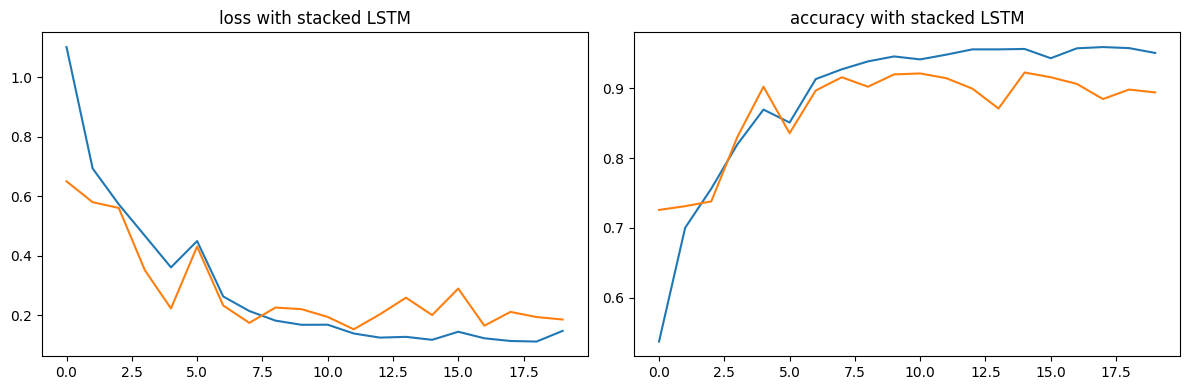

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history3.history['loss'],     label='train')
ax1.plot(history3.history['val_loss'], label='val')
ax1.set_title('loss with stacked LSTM')
ax2.plot(history3.history['accuracy'],     label='train')
ax2.plot(history3.history['val_accuracy'], label='val')
ax2.set_title("accuracy with stacked LSTM")
plt.tight_layout()
plt.show()

#### Findings

We also achieve very good performance by stacking LSTM layers with 16, 32 and 64 nunits : **87.92%**. 

### CNN (Conv1d)

In [22]:
# reshape dataset for cnn
X_train = X_train.reshape((X_train.shape[0], 128, 9, 1))
X_test = X_test.reshape((X_test.shape[0], 128, 9, 1))

In [23]:
### START YOUR CODE

model4 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128, 9, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

model4.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

model4.summary()

### END YOUR CODE

/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 9, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 4, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 4, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 2, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,878 (2.11 MB)

 Trainable params: 551,878 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
### START YOUR CODE
history4 = model4.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss4, test_acc4 = model4.evaluate(X_test, Y_test)
print(f"\nAccuracy: {test_acc4:.4f}")


Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7361 - loss: 0.6271 - val_accuracy: 0.7568 - val_loss: 0.4965
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8968 - loss: 0.2712 - val_accuracy: 0.9185 - val_loss: 0.1783
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9305 - loss: 0.1832 - val_accuracy: 0.9144 - val_loss: 0.1613
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9506 - loss: 0.1322 - val_accuracy: 0.9022 - val_loss: 0.2271
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9541 - loss: 0.1232 - val_accuracy: 0.9185 - val_loss: 0.1906
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9578 - loss: 0.1094 - val_accuracy: 0.9348 - val_loss: 0.1196
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9562 - loss: 0.1146 - val_accuracy: 0.9185 - val_loss: 0.1285
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9566 - loss: 0.1053 - val_accu

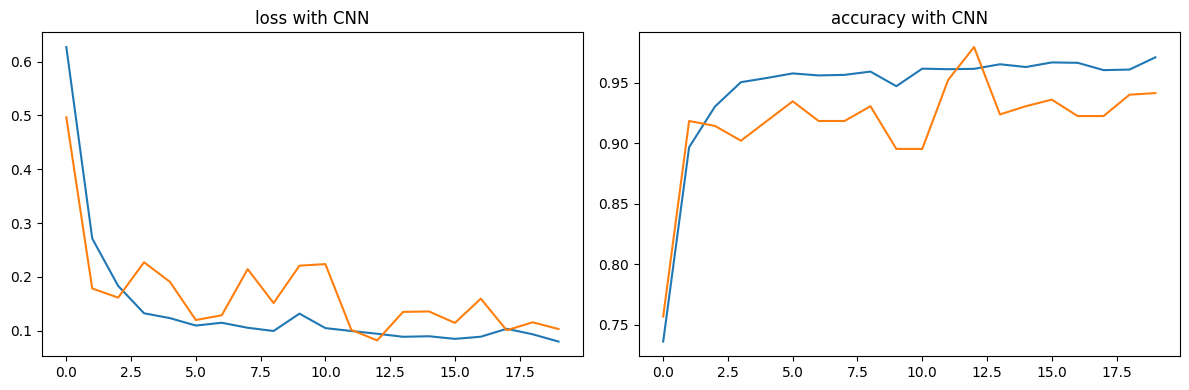

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history4.history['loss'],     label='train')
ax1.plot(history4.history['val_loss'], label='val')
ax1.set_title('loss with CNN')
ax2.plot(history4.history['accuracy'],     label='train')
ax2.plot(history4.history['val_accuracy'], label='val')
ax2.set_title("accuracy with CNN")
plt.tight_layout()
plt.show()

#### Findings

We achieve **92.64%** of accuracy by a CNN model. The traning remains a bit instable.

### MLP

In [31]:
# reshape for mlp
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

In [32]:
### START YOUR CODE

model5= tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(1152,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

model5.compile(loss="categorical_crossentropy", optimizer="adam", metrics=['accuracy'])

model5.summary()
### END YOUR CODE

/home/lena/.venvs/mon-venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 336,710 (1.28 MB)

 Trainable params: 336,710 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
### START YOUR CODE
history5 = model5.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss5, test_acc5 = model5.evaluate(X_test, Y_test)
print(f"\nAccuracy: {test_acc5:.4f}")


Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7934 - loss: 0.5489 - val_accuracy: 0.8696 - val_loss: 0.3405
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9358 - loss: 0.1834 - val_accuracy: 0.8560 - val_loss: 0.3626
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9527 - loss: 0.1250 - val_accuracy: 0.9117 - val_loss: 0.2177
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9568 - loss: 0.1094 - val_accuracy: 0.9144 - val_loss: 0.1617
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9577 - loss: 0.0985 - val_accuracy: 0.9117 - val_loss: 0.2662
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9610 - loss: 0.0924 - val_accuracy: 0.9171 - val_loss: 0.2802
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9606 - loss: 0.0914 - val_accuracy: 0.9158 - val_loss: 0.2733
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9618 - loss: 0.0896 - val_accuracy: 0.

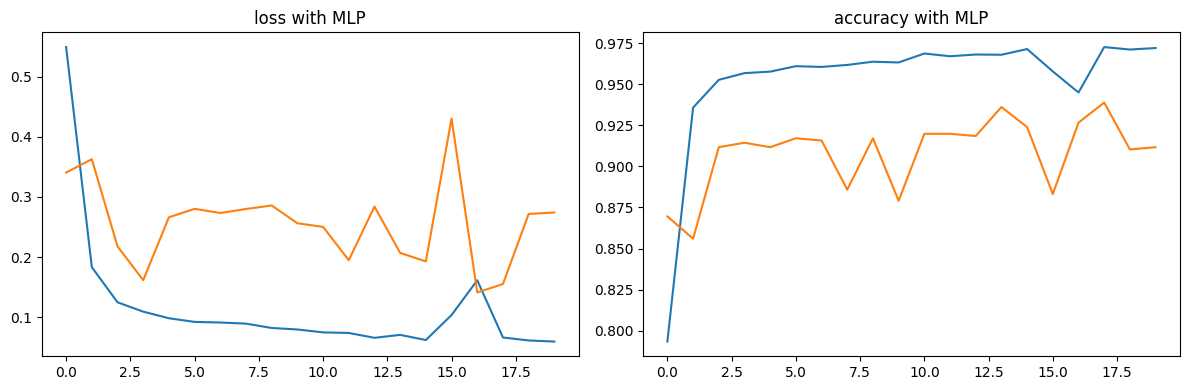

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history5.history['loss'],     label='train')
ax1.plot(history5.history['val_loss'], label='val')
ax1.set_title('loss with MLP')
ax2.plot(history5.history['accuracy'],     label='train')
ax2.plot(history5.history['val_accuracy'], label='val')
ax2.set_title("accuracy with MLP")
plt.tight_layout()
plt.show()

#### Findings

Results are less satisfaying with the MLP with **88.23%** of accuracy.


__________________________

**Conclusion**

For the dataset UCI HAR, the best performances will be achieve with the CNN and RNN/LSTM. Indeed, a CNN can capture local patterns and, RNN and LSTM time dependencies. The best choice seems to be the CNN because because the accuracy is better while the complexity is lower. Indeed, the complexity of LSTM can be high with the RNN cells and its gates. In contrary, MLP cannot catch temporal structure and is inappropriate for this use case.